In [2]:
# Data Loading and Data Understanding

# Import Libraries
import pandas as pd
import numpy as np

# Load Dataset

df = pd.read_csv("ToyotaCorolla - MLR.csv")

# First 5 rows

print(df.head())
print('='*50)

# Last 5 rows

print(df.tail())


# Shape

print('shape of the dataset:',df.shape)

# Columns


print('columns:\n',df.columns)

# Dataset Information


print('Dataset information:\n',df.info())


# Statistical Summary

print('Summary of the dataset:\n',df.describe())

# Missing Values

print('no of missing values:\n',df.isnull().sum())


# Duplicate Values

print('no of duplicate records:\n',df.duplicated().sum())


   Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
0  13500         23  46986    Diesel  90          0  2000      3          4   
1  13750         23  72937    Diesel  90          0  2000      3          4   
2  13950         24  41711    Diesel  90          0  2000      3          4   
3  14950         26  48000    Diesel  90          0  2000      3          4   
4  13750         30  38500    Diesel  90          0  2000      3          4   

   Gears  Weight  
0      5    1165  
1      5    1165  
2      5    1165  
3      5    1165  
4      5    1170  
      Price  Age_08_04     KM Fuel_Type   HP  Automatic    cc  Doors  \
1431   7500         69  20544    Petrol   86          0  1300      3   
1432  10845         72  19000    Petrol   86          0  1300      3   
1433   8500         71  17016    Petrol   86          0  1300      3   
1434   7250         70  16916    Petrol   86          0  1300      3   
1435   6950         76      1    Petrol  110       

In [3]:
# Data Cleaning

# Remove Duplicate Rows
df.drop_duplicates(inplace=True)

# Missing Values
df.isnull().sum()

# Fill Numerical Missing Values
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill Categorical Missing Values
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

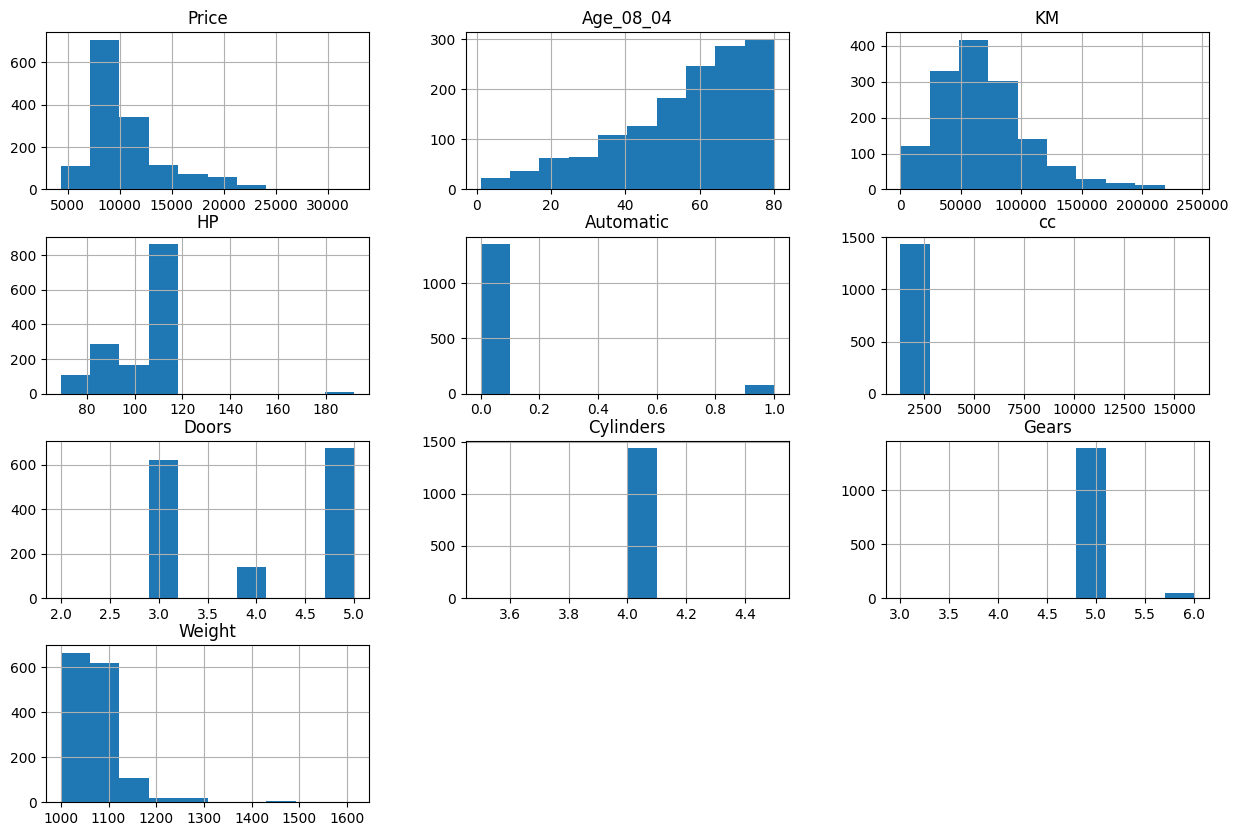

In [4]:
# EXPLOLATORY DATA ANALYSIS(EDA)

import matplotlib.pyplot as plt
import seaborn as sns

# Histogram

df.hist(figsize=(15,10))
plt.show()

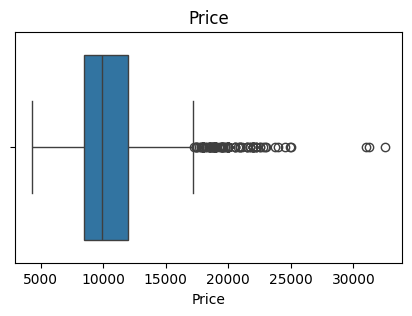

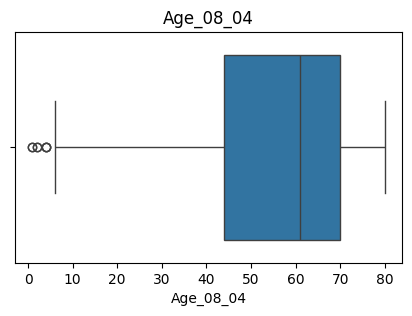

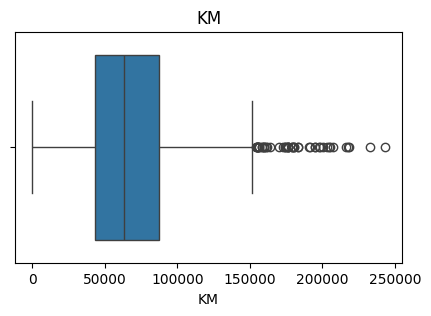

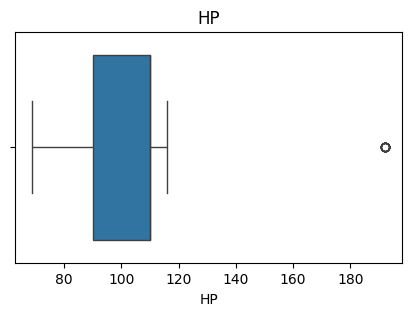

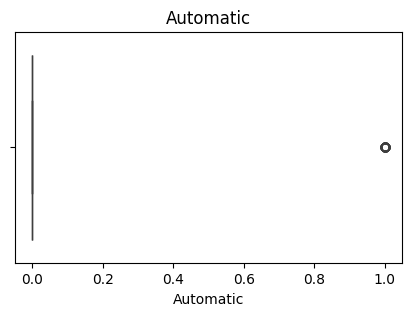

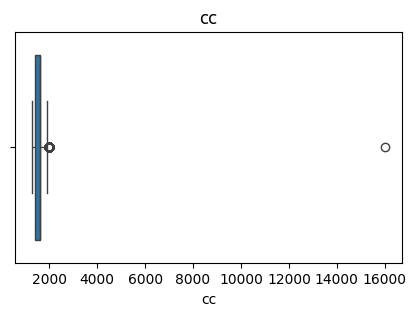

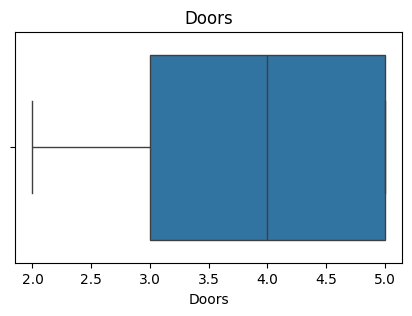

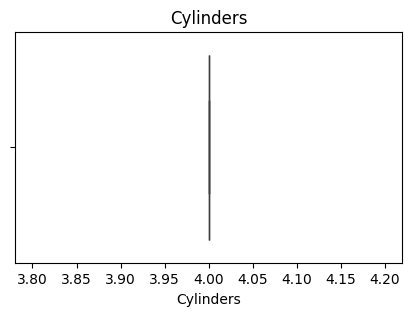

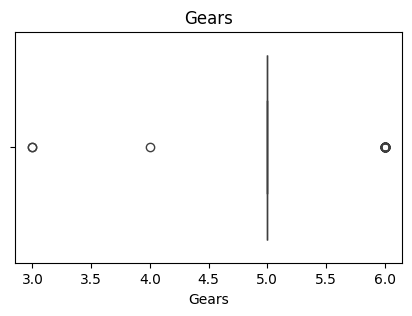

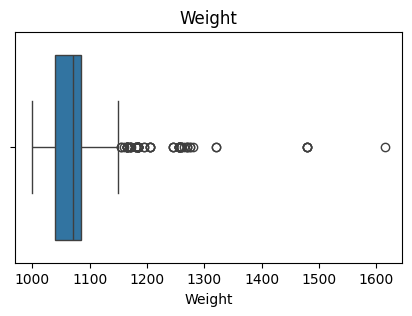

In [5]:
# Boxplot

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:

    plt.figure(figsize=(5,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

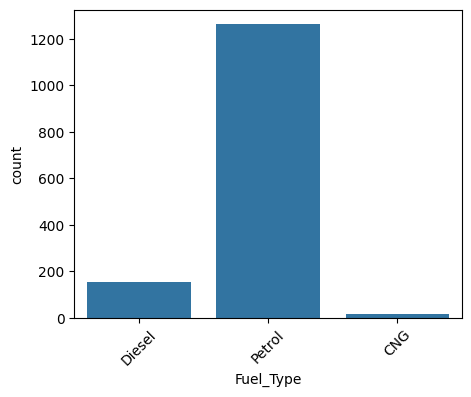

In [6]:
# Countplot

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:

    plt.figure(figsize=(5,4))

    sns.countplot(x=df[col])

    plt.xticks(rotation=45)

    plt.show()

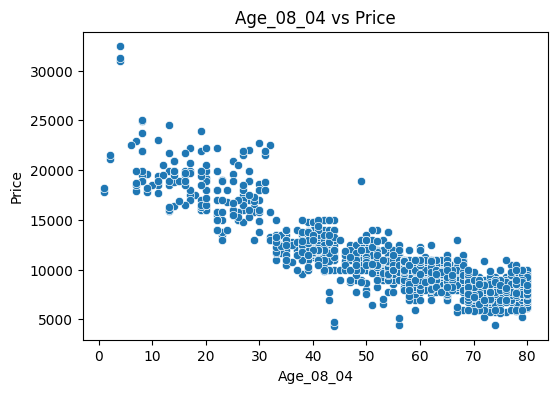

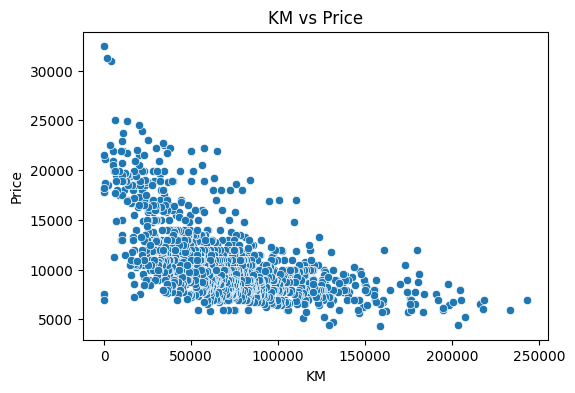

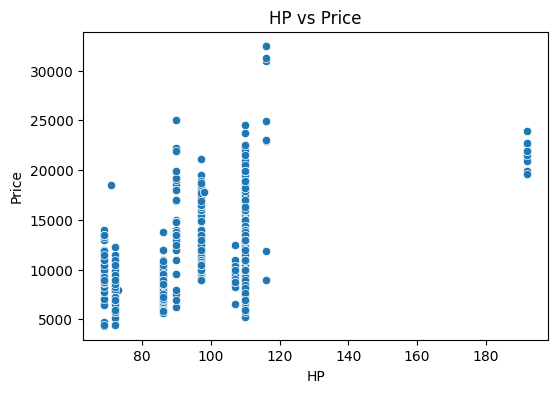

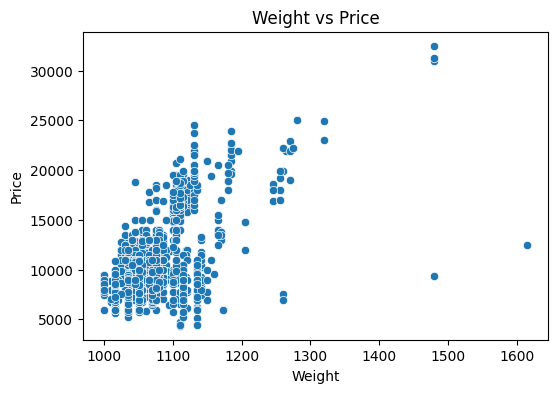

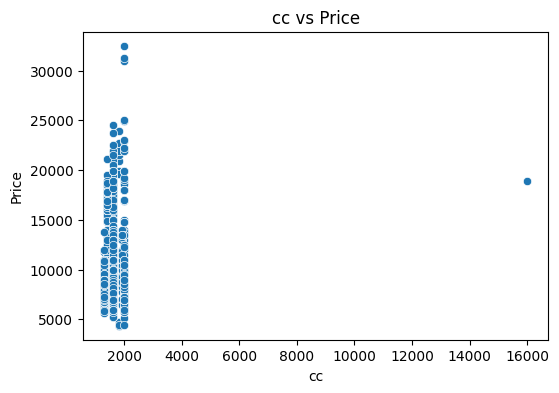

In [7]:
# ScatterPlot

features=['Age_08_04','KM','HP','Weight','cc']

for col in features:

    plt.figure(figsize=(6,4))

    sns.scatterplot(x=df[col],y=df['Price'])

    plt.title(f'{col} vs Price')

    plt.show()

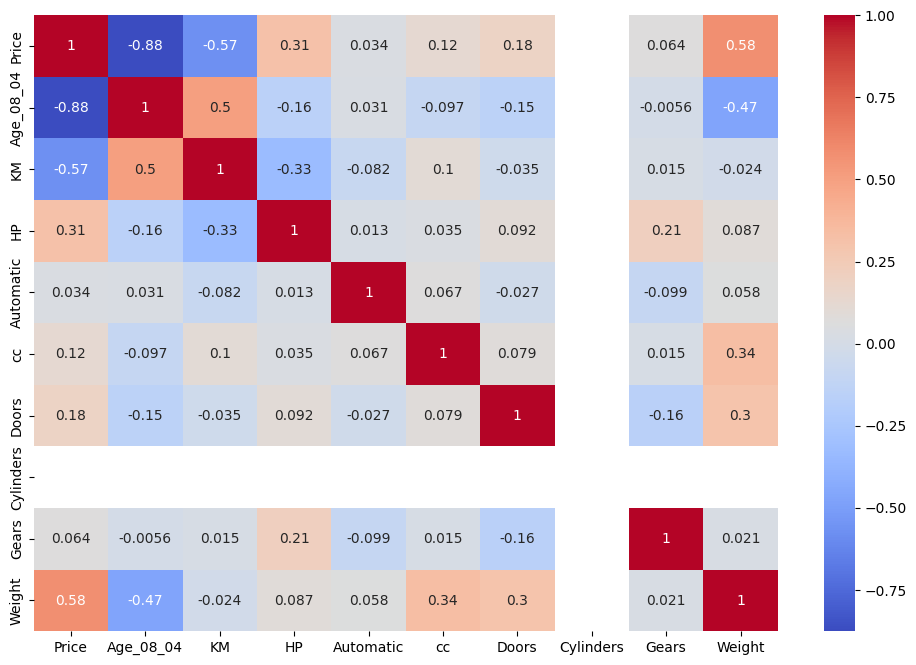

In [8]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()

    1.Histograms were plotted for all numerical variables to examine their distributions. Some variables showed approximately normal distributions, while others were slightly skewed.
    2.Boxplots were used to detect potential outliers. Outliers were observed in variables such as Price, KM, HP, cc, and Weight. After examination, these values were retained because they represent valid vehicle characteristics rather than data-entry errors.
    3.Count plots were generated for categorical variables, particularly Fuel_Type, to understand the frequency distribution of petrol, diesel, and CNG vehicles.
    4.Scatter plots were created between important predictor variables (Age_08_04, KM, HP, Weight, and cc) and the target variable (Price). The plots indicated mostly linear relationships, suggesting that Multiple Linear Regression is an appropriate modeling technique.
    5.A correlation heatmap was generated to analyze relationships among numerical variables

In [9]:
# Data Transformation

#Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])

# Remove the constant Column

df.drop('Cylinders',axis=1,inplace=True)

# Features and Target

X = df.drop('Price',axis=1)

y = df['Price']

In [10]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.20,
random_state=42)

In [11]:
# standard Scaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [12]:
# Building Models


# model 1 

from sklearn.linear_model import LinearRegression

model1=LinearRegression()

model1.fit(X_train,y_train) # model fitting

y_pred1=model1.predict(X_test) # model prediction

# Coefficients

coef=pd.DataFrame({

'Feature':X.columns,

'Coefficient':model1.coef_

})

print(coef)

# model 2

features2=['Age_08_04','KM','HP','Weight']

X2=df[features2]

y=df['Price']

X_train2,X_test2,y_train2,y_test2=train_test_split(
X2,
y,
test_size=0.20,
random_state=42)

scaler=StandardScaler()

X_train2=scaler.fit_transform(X_train2)

X_test2=scaler.transform(X_test2)

model2=LinearRegression()

model2.fit(X_train2,y_train2)

y_pred2=model2.predict(X_test2)


# model 3


features3=['Age_08_04','KM','Fuel_Type','Weight']

X3=df[features3]

y=df['Price']

X_train3,X_test3,y_train3,y_test3=train_test_split(
X3,
y,
test_size=0.20,
random_state=42)

scaler=StandardScaler()

X_train3=scaler.fit_transform(X_train3)

X_test3=scaler.transform(X_test3)

model3=LinearRegression()

model3.fit(X_train3,y_train3)

y_pred3=model3.predict(X_test3)

     Feature  Coefficient
0  Age_08_04 -2278.022440
1         KM  -635.536071
2  Fuel_Type   314.404687
3         HP   354.509019
4  Automatic    83.561469
5         cc   -44.962888
6      Doors   -57.471294
7      Gears    79.627995
8     Weight  1194.948820


In [14]:
# Model Evalution

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

print("Model 1")

print("MAE :",np.round(mean_absolute_error(y_test,y_pred1),4))

print("MSE :",np.round(mean_squared_error(y_test,y_pred1),4))

print("RMSE :",np.sqrt(mean_squared_error(y_test,y_pred1)))

print("R2 :",np.round(r2_score(y_test,y_pred1),4))

print('*'*50)

print("Model 2")

print("MAE :",np.round(mean_absolute_error(y_test2,y_pred2),4))

print("MSE :",np.round(mean_squared_error(y_test2,y_pred2),4))

print("RMSE :",np.sqrt(mean_squared_error(y_test2,y_pred2)))

print("R2 :",np.round(r2_score(y_test2,y_pred2),4))

print('*'*50)

print("Model 3")

print("MAE :",np.round(mean_absolute_error(y_test3,y_pred3),4))

print("MSE :",np.round(mean_squared_error(y_test3,y_pred3),4))

print("RMSE :",np.sqrt(mean_squared_error(y_test3,y_pred3)))

print("R2 :",np.round(r2_score(y_test3,y_pred3),4))

Model 1
MAE : 976.2714
MSE : 2006554.2201
RMSE : 1416.5289337378665
R2 : 0.8327
**************************************************
Model 2
MAE : 987.2253
MSE : 1934478.8194
RMSE : 1390.855427204096
R2 : 0.8388
**************************************************
Model 3
MAE : 947.7203
MSE : 2150522.235
RMSE : 1466.4658997154836
R2 : 0.8207


In [15]:
# Ridge Regression


from sklearn.linear_model import Ridge

ridge=Ridge(alpha=1)

ridge.fit(X_train,y_train)

ridge_pred=ridge.predict(X_test)

print("R2 :",r2_score(y_test,ridge_pred))

R2 : 0.8328379398076752


In [16]:
# Lasso Regression


from sklearn.linear_model import Lasso

lasso=Lasso(alpha=1)

lasso.fit(X_train,y_train)

lasso_pred=lasso.predict(X_test)

print("R2 :",r2_score(y_test,lasso_pred))

R2 : 0.8329507688179233


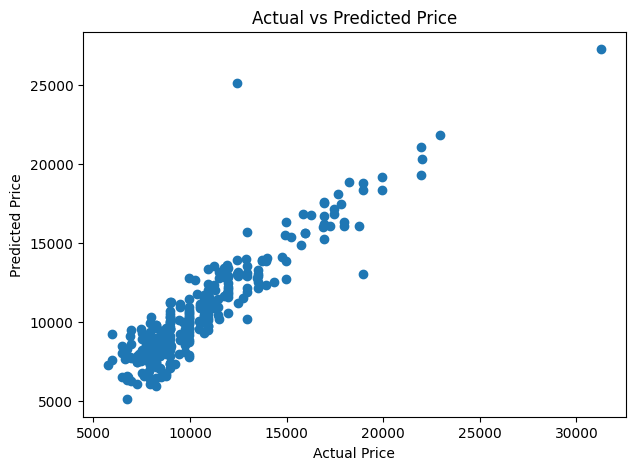

In [17]:
# Actual vs Predicted price


plt.figure(figsize=(7,5))

plt.scatter(y_test,y_pred1)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

1. Normalization is a data preprocessing technique that scales numerical values between 0 and 1. 
    It is useful when features have different ranges and is commonly used with algorithms such as KNN and Neural Networks.
2. Standardization transforms data so that it has a mean of 0 and a standard deviation of 1. 
    It is widely used in Linear Regression, Ridge Regression, Lasso Regression, and Support Vector Machines because it ensures that all features contribute equally to the model

2. What techniques can be used to address multicollinearity in Multiple Linear Regression?

Multicollinearity occurs when two or more independent variables are highly correlated.

Techniques to address multicollinearity include:
1. Correlation analysis
2. Variance Inflation Factor (VIF)
3. Removing highly correlated features
4. Feature selection
5. Ridge Regression
6. Lasso Regression 

 Assumptions Made During the Analysis

1. Duplicate records were removed.
2. Missing values were handled.
3. Valid outliers were retained.
4. Fuel_Type was encoded.
5. Features were standardized before applying Ridge and Lasso Regression.
6. The dataset was split into 80% training data and 20% testing data.
7. A linear relationship between the predictors and the target variable was assumed.